#Task 6: High-Throughput Asynchronous RAG Pipeline with Cross-Encoder Reranking
###Objective

Construct an enterprise-ready Retrieval-Augmented Generation (RAG) system with complex dual-stage retrieval and real-time asynchronous routing.

###Technologies / Tools Used
Python,
FastAPI,
LangChain,
FAISS,
PyTorch,
SentenceTransformers,
Asyncio

#Step 1: Install Required Libraries

Install the libraries needed for the RAG pipeline.

In [4]:
# Install the required libraries
!pip install -q fastapi uvicorn langchain langchain-community sentence-transformers faiss-cpu

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


#Step 2: Import Required Libraries

Import the libraries used in the RAG system.

In [5]:
# Import asyncio for asynchronous processing
import asyncio

# Import time for measuring response time
import time

# Import PyTorch
import torch

# Import SentenceTransformer for embeddings
from sentence_transformers import SentenceTransformer, CrossEncoder

# Import LangChain document structure
from langchain_core.documents import Document

# Import LangChain FAISS vector store
from langchain_community.vectorstores import FAISS

# Import Hugging Face embeddings for LangChain
from langchain_community.embeddings import HuggingFaceEmbeddings

print("Libraries imported successfully.")

/tmp/ipykernel_1127/3981801591.py:17: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


Libraries imported successfully.


#Step 3: Create Sample Documents

Create a small collection of documents that will act as our knowledge base.

These documents can represent company information, articles, legal documents, or any other knowledge

In [6]:
# Create sample knowledge documents
documents = [
    Document(
        page_content="Artificial intelligence allows computers to perform tasks that normally require human intelligence."
    ),
    Document(
        page_content="Machine learning is a branch of artificial intelligence that learns patterns from data."
    ),
    Document(
        page_content="Deep learning uses neural networks with multiple layers to learn complex patterns."
    ),
    Document(
        page_content="Natural language processing allows computers to understand and process human language."
    ),
    Document(
        page_content="Retrieval-Augmented Generation combines information retrieval with language generation."
    ),
    Document(
        page_content="Vector databases store numerical representations of data and support similarity search."
    )
]

print("Number of documents:", len(documents))

Number of documents: 6


#Step 4: Create the Bi-Encoder Embedding Model

Use a SentenceTransformer model to convert documents into vector embeddings

This is the first stage of retrieval.

In [7]:
# Load the embedding model
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded.")

/tmp/ipykernel_1127/1601138494.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


#Step 5: Create the FAISS Vector Index

Convert the documents into vectors and store them in a FAISS index.

FAISS allows us to quickly search for vectors similar to the query.

In [8]:

# Create a FAISS vector database
vector_store = FAISS.from_documents(
    documents,
    embedding_model
)

print("FAISS vector index created successfully.")

FAISS vector index created successfully.


#Step 6: Perform First-Stage Retrieval

Search the FAISS index using a user query.

The bi-encoder retrieves the most relevant candidate documents.

In [9]:
# User query
query = "What is artificial intelligence?"

# Retrieve the top candidate documents
candidates = vector_store.similarity_search(
    query,
    k=4
)

print("Retrieved Candidates:\n")

for i, document in enumerate(candidates, start=1):
    print(i, document.page_content)

Retrieved Candidates:

1 Artificial intelligence allows computers to perform tasks that normally require human intelligence.
2 Machine learning is a branch of artificial intelligence that learns patterns from data.
3 Natural language processing allows computers to understand and process human language.
4 Deep learning uses neural networks with multiple layers to learn complex patterns.


#Step 7: Load the Cross-Encoder

Load a cross-encoder model.

The cross-encoder examines the query and document together, allowing us to rerank the candidate documents more accurately.

In [10]:
# Load cross-encoder reranking model
reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

print("Cross-encoder loaded.")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Cross-encoder loaded.


#Step 8: Rerank the Retrieved Documents

Pass the query and retrieved documents to the cross-encoder.

The documents are then sorted according to their relevance score.

In [11]:
# Create query-document pairs
pairs = []

for document in candidates:

    pairs.append(
        (
            query,
            document.page_content
        )
    )

# Calculate relevance scores
scores = reranker.predict(pairs)

# Combine documents and scores
ranked_results = list(
    zip(candidates, scores)
)

# Sort by score
ranked_results.sort(
    key=lambda x: x[1],
    reverse=True
)

print("Reranked Results:\n")

for i, (document, score) in enumerate(
    ranked_results,
    start=1
):
    print(
        i,
        "Score:",
        round(float(score), 4)
    )

    print(
        document.page_content
    )

    print()

Reranked Results:

1 Score: 8.6136
Artificial intelligence allows computers to perform tasks that normally require human intelligence.

2 Score: 2.0717
Machine learning is a branch of artificial intelligence that learns patterns from data.

3 Score: -9.9099
Natural language processing allows computers to understand and process human language.

4 Score: -11.0134
Deep learning uses neural networks with multiple layers to learn complex patterns.



#Step 9: Create an Asynchronous LLM Synthesis Function

Create an asynchronous function that generates a response from the retrieved contexts.

For this practical, we use a simple local synthesis function instead of an external LLM API. This keeps the notebook free from API keys and authentication.

In [12]:
# Asynchronous response generation
async def generate_response(
    query,
    contexts
):

    # Simulate LLM processing time
    await asyncio.sleep(0.2)

    # Combine retrieved information
    context_text = " ".join(
        contexts
    )

    # Create a simple response
    response = (
        "Answer based on retrieved information: "
        + context_text
    )

    return response

#Step 10: Build the Asynchronous RAG Pipeline

Combine retrieval, reranking, and response generation into one asynchronous pipeline

In [13]:
# Complete asynchronous RAG function
async def rag_pipeline(query):

    start_time = time.time()

    # First stage: vector retrieval
    candidates = vector_store.similarity_search(
        query,
        k=4
    )

    # Create query-document pairs
    pairs = [
        (
            query,
            document.page_content
        )
        for document in candidates
    ]

    # Second stage: cross-encoder reranking
    scores = reranker.predict(
        pairs
    )

    # Combine documents with scores
    ranked_results = list(
        zip(candidates, scores)
    )

    # Sort by relevance
    ranked_results.sort(
        key=lambda x: x[1],
        reverse=True
    )

    # Select top documents
    top_documents = [
        document.page_content
        for document, score
        in ranked_results[:2]
    ]

    # Generate response asynchronously
    response = await generate_response(
        query,
        top_documents
    )

    # Calculate latency
    latency = time.time() - start_time

    return response, latency

#Step 11: Test the Asynchronous RAG Pipeline

Run the complete RAG pipeline with a sample query.

In [14]:
# Run the asynchronous RAG pipeline
query = "What is machine learning?"

response, latency = await rag_pipeline(
    query
)

print("Query:")
print(query)

print("\nResponse:")
print(response)

print("\nLatency:")
print(round(latency, 4), "seconds")

Query:
What is machine learning?

Response:
Answer based on retrieved information: Machine learning is a branch of artificial intelligence that learns patterns from data. Deep learning uses neural networks with multiple layers to learn complex patterns.

Latency:
0.533 seconds


#Step 12: Process Multiple Queries Concurrently

Use asyncio.gather() to process multiple queries concurrently.

This demonstrates asynchronous request handling.

In [15]:
# Create multiple user queries
queries = [
    "What is artificial intelligence?",
    "What is machine learning?",
    "What is deep learning?",
    "What is natural language processing?"
]


# Function to process one query
async def process_query(query):

    response, latency = await rag_pipeline(
        query
    )

    return query, response, latency


# Start timer
start_time = time.time()

# Process all queries concurrently
results = await asyncio.gather(
    *[
        process_query(query)
        for query in queries
    ]
)

# Total processing time
total_time = time.time() - start_time


# Display results
for query, response, latency in results:

    print("Query:", query)

    print("Latency:", round(latency, 4), "seconds")

    print("Response:", response[:150])

    print("-" * 50)


print(
    "\nTotal concurrent processing time:",
    round(total_time, 4),
    "seconds"
)

Query: What is artificial intelligence?
Latency: 0.5548 seconds
Response: Answer based on retrieved information: Artificial intelligence allows computers to perform tasks that normally require human intelligence. Machine lea
--------------------------------------------------
Query: What is machine learning?
Latency: 0.377 seconds
Response: Answer based on retrieved information: Machine learning is a branch of artificial intelligence that learns patterns from data. Deep learning uses neur
--------------------------------------------------
Query: What is deep learning?
Latency: 0.3073 seconds
Response: Answer based on retrieved information: Deep learning uses neural networks with multiple layers to learn complex patterns. Machine learning is a branch
--------------------------------------------------
Query: What is natural language processing?
Latency: 0.352 seconds
Response: Answer based on retrieved information: Natural language processing allows computers to understand and process hum

#Step 13: Create a FastAPI RAG Service

Create a simple FastAPI application that can receive client queries.

In [16]:
# Import FastAPI
from fastapi import FastAPI

# Create FastAPI application
app = FastAPI(
    title="Async RAG Service"
)


# Define the RAG endpoint
@app.get("/query")
async def query_rag(
    question: str
):

    # Run the RAG pipeline
    response, latency = await rag_pipeline(
        question
    )

    # Return the result
    return {
        "question": question,
        "answer": response,
        "latency": latency
    }


print("FastAPI application created.")

FastAPI application created.


#Step 14: Visualize Retrieval and Reranking

Visualize the relevance scores assigned by the cross-encoder.

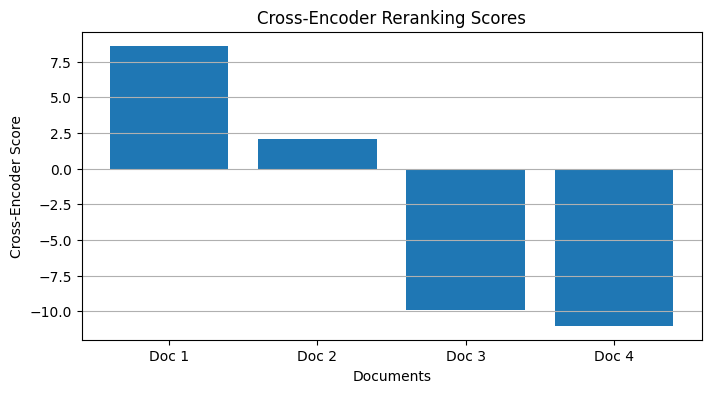

In [17]:
# Import Matplotlib
import matplotlib.pyplot as plt

# Get document names
document_numbers = [
    f"Doc {i}"
    for i in range(
        1,
        len(ranked_results) + 1
    )
]

# Get relevance scores
rerank_scores = [
    float(score)
    for document, score
    in ranked_results
]

# Create graph
plt.figure(figsize=(8, 4))

plt.bar(
    document_numbers,
    rerank_scores
)

plt.xlabel("Documents")
plt.ylabel("Cross-Encoder Score")

plt.title(
    "Cross-Encoder Reranking Scores"
)

plt.grid(axis="y")

plt.show()

#Conclusion

The asynchronous RAG pipeline was implemented using a two-stage retrieval process. FAISS with a SentenceTransformer bi-encoder first retrieves candidate documents, and a CrossEncoder then reranks those candidates according to query-document relevance. An asynchronous pipeline using asyncio handles multiple queries concurrently, while FastAPI provides an interface for client requests.

The visualization shows the relevance scores produced by the cross-encoder, making the reranking stage easier to observe.